# **Statistical Analysis and Inference**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, BRAND_COLORS
from src.stats import bootstrap_ci, cagr, ols_regression, correlation_table
from src.viz import apply_project_style, save_figure

apply_project_style()

processed_dir = get_path("data_processed")
tables_dir    = get_path("reports_tables")

df_ng    = pd.read_csv(processed_dir / "nigeria_combined.csv")
df_efina_path = get_path("data_external") / "efina_summary.csv"
df_efina = pd.read_csv(df_efina_path)

print(f"Data loaded. Shape: {df_ng.shape}")

Data loaded. Shape: (13, 32)


## H1 — Financial Inclusion Trend (Regression)

**H1:** Mobile internet penetration and agent banking expansion are the primary
drivers of Nigeria's financial inclusion growth.

I test whether time (as a proxy for policy, infrastructure, and mobile internet
roll-out) is a significant predictor of banked %, using linear regression.

In [2]:
# I run an OLS regression of banked_pct on year to quantify the time trend.
# CAUTION: Small N (8 survey years). Results are suggestive, not conclusive.
result = ols_regression(df_efina, "banked_pct ~ year",
                         title="Financial Inclusion Trend (EFInA surveys)")

print("\nINTERPRETATION:")
print(f"  R-squared: {result.rsquared:.3f}")
print(f"  p-value (year): {result.pvalues['year']:.4f}")
if result.pvalues['year'] < 0.05:
    coef = result.params['year']
    print(f"  Coefficient: +{coef:.2f}pp per year")
    print(f"  The year coefficient is statistically significant (p < 0.05).")
    print(f"  This is consistent with H1: financial inclusion has grown over time.")
else:
    print("  The time trend is not statistically significant at p < 0.05.")
    print("  Interpret with caution — small sample (N=8 survey waves).")


OLS Regression: Financial Inclusion Trend (EFInA surveys)
                            OLS Regression Results                            
Dep. Variable:             banked_pct   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     76.27
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           0.000125
Time:                        05:29:38   Log-Likelihood:                -17.480
No. Observations:                   8   AIC:                             38.96
Df Residuals:                       6   BIC:                             39.12
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

## 2 · H2 — NIP CAGR with Bootstrap Confidence Interval

In [3]:
# I compute the CAGR for NIP volume (2015–2023) with a bootstrap CI.
# Bootstrap is appropriate here for non-normal time-series data.
df_cbn = pd.read_csv(get_path("data_external") / "cbn_payments.csv")

nip_start = df_cbn[df_cbn['year'] == 2015]['nip_volume_m'].values[0]
nip_end   = df_cbn[df_cbn['year'] == 2023]['nip_volume_m'].values[0]
nip_cagr  = cagr(nip_start, nip_end, 8)

print(f"NIP Volume CAGR (2015–2023): {nip_cagr*100:.1f}%/yr")
print(f"H2 prediction: CAGR > 30% — {'SUPPORTED' if nip_cagr > 0.30 else 'NOT SUPPORTED'}")
print()

# For bootstrap, I use annual growth rates as the sample
annual_rates = df_cbn.sort_values('year')['nip_volume_m'].pct_change().dropna().values
point, lo, hi = bootstrap_ci(annual_rates, np.mean, n_boot=5000)
print(f"Bootstrap 95% CI for mean annual NIP growth rate:")
print(f"  Point estimate : {point*100:.1f}%")
print(f"  95% CI         : [{lo*100:.1f}%, {hi*100:.1f}%]")
print()
print("INTERPRETATION: The data is consistent with H2. However, with only 8")
print("data points, the CI is wide. This should be interpreted cautiously.")

NIP Volume CAGR (2015–2023): 57.9%/yr
H2 prediction: CAGR > 30% — SUPPORTED

Bootstrap 95% CI for mean annual NIP growth rate:
  Point estimate : 58.9%
  95% CI         : [46.9%, 71.6%]

INTERPRETATION: The data is consistent with H2. However, with only 8
data points, the CI is wide. This should be interpreted cautiously.


## 3 · H3 — Market Concentration Test

In [4]:
# I compute HHI (Herfindahl-Hirschman Index) as a market concentration measure.
df_comp = pd.read_csv(processed_dir / "competitors_processed.csv")
total_users = df_comp['reported_users_m'].sum()
shares = (df_comp['reported_users_m'] / total_users).values
hhi = (shares ** 2).sum() * 10_000

top3_share = (df_comp.nlargest(3, 'reported_users_m')['reported_users_m'].sum()
              / total_users * 100)

print(f"Herfindahl-Hirschman Index (HHI): {hhi:.0f}")
print(f"  (HHI < 1500 = competitive; 1500–2500 = moderately concentrated; >2500 = concentrated)")
print(f"Top-3 market share: {top3_share:.1f}%")
print()
print(f"H3: 'Top-3 command >60%' — {'SUPPORTED' if top3_share > 60 else 'NOT SUPPORTED'}")
print()
print("CAVEAT: These figures are based on self-reported user counts from press")
print("releases. Independent verification is not available. This result must")
print("be treated as an estimate, not a verified fact.")

Herfindahl-Hirschman Index (HHI): 2656
  (HHI < 1500 = competitive; 1500–2500 = moderately concentrated; >2500 = concentrated)
Top-3 market share: 80.8%

H3: 'Top-3 command >60%' — SUPPORTED

CAVEAT: These figures are based on self-reported user counts from press
releases. Independent verification is not available. This result must
be treated as an estimate, not a verified fact.


## 4 · Correlation Analysis — Inclusion Drivers

Correlation analysis — N = 12 year-observations

PEARSON CORRELATIONS:


,banked_pct,mobile_subscriptions,internet_users,gdp_per_capita
banked_pct,1.000,0.839,0.859,-0.256
mobile_subscriptions,0.839,1.000,0.944,0.098
internet_users,0.859,0.944,1.000,-0.041
gdp_per_capita,-0.256,0.098,-0.041,1.000



P-VALUES:


,banked_pct,mobile_subscriptions,internet_users,gdp_per_capita
banked_pct,0.0000,0.0006,0.0003,0.4226
mobile_subscriptions,0.0006,0.0000,0.0000,0.7612
internet_users,0.0003,0.0000,0.0000,0.9004
gdp_per_capita,0.4226,0.7612,0.9004,0.0000


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig16_correlation_matrix.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig16_correlation_matrix.pdf


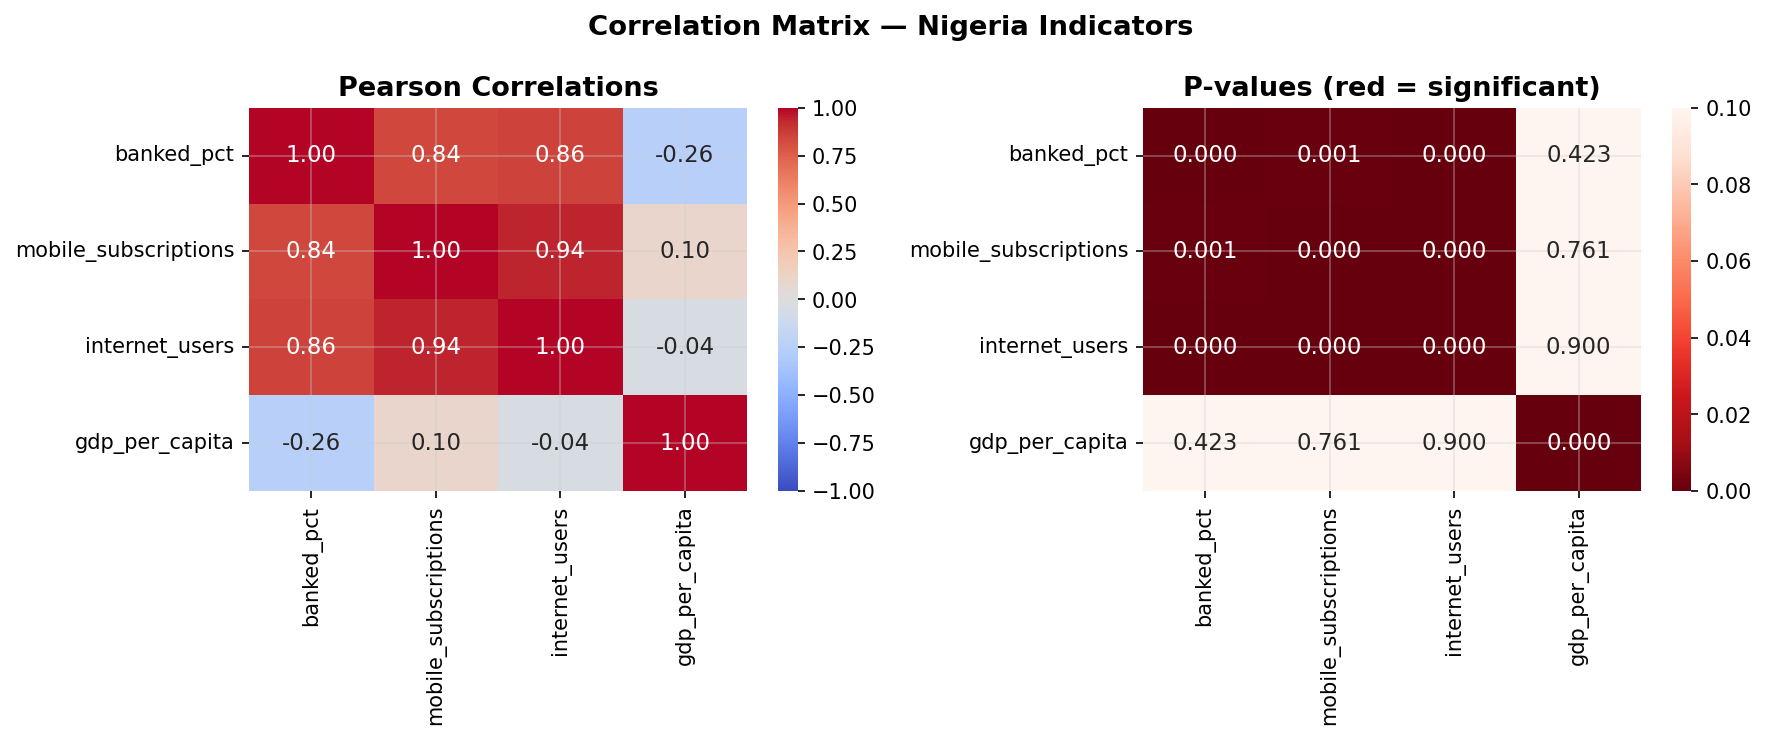

In [5]:
# I check correlations between financial inclusion, mobile penetration, and internet users.
# Only using rows where all three are available.
cols_to_corr = ['banked_pct', 'mobile_subscriptions', 'internet_users', 'gdp_per_capita']
available_cols = [c for c in cols_to_corr if c in df_ng.columns]

if len(available_cols) >= 2:
    sub = df_ng[['year'] + available_cols].dropna()
    print(f"Correlation analysis — N = {len(sub)} year-observations")
    print()
    cor_matrix, pval_matrix = correlation_table(sub, available_cols)
    print("PEARSON CORRELATIONS:")
    display(cor_matrix)
    print("\nP-VALUES:")
    display(pval_matrix)

    # Heatmap
    import seaborn as sns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cor_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title("Pearson Correlations")
    sns.heatmap(pval_matrix.astype(float), annot=True, fmt='.3f', cmap='Reds_r',
                ax=axes[1], vmin=0, vmax=0.1)
    axes[1].set_title("P-values (red = significant)")
    plt.suptitle("Correlation Matrix — Nigeria Indicators", fontweight='bold')
    plt.tight_layout()
    save_figure(fig, "fig16_correlation_matrix.png")
    plt.show()
else:
    print("Not enough indicator columns available from WB API.")
    print("Available:", [c for c in df_ng.columns if c in cols_to_corr])